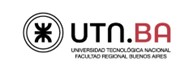

###**Trabajo Semanal 4**
**Teoria de los Circuitos 2**


Autor: Alan Nicolas Parizek


Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: César Fuoco  




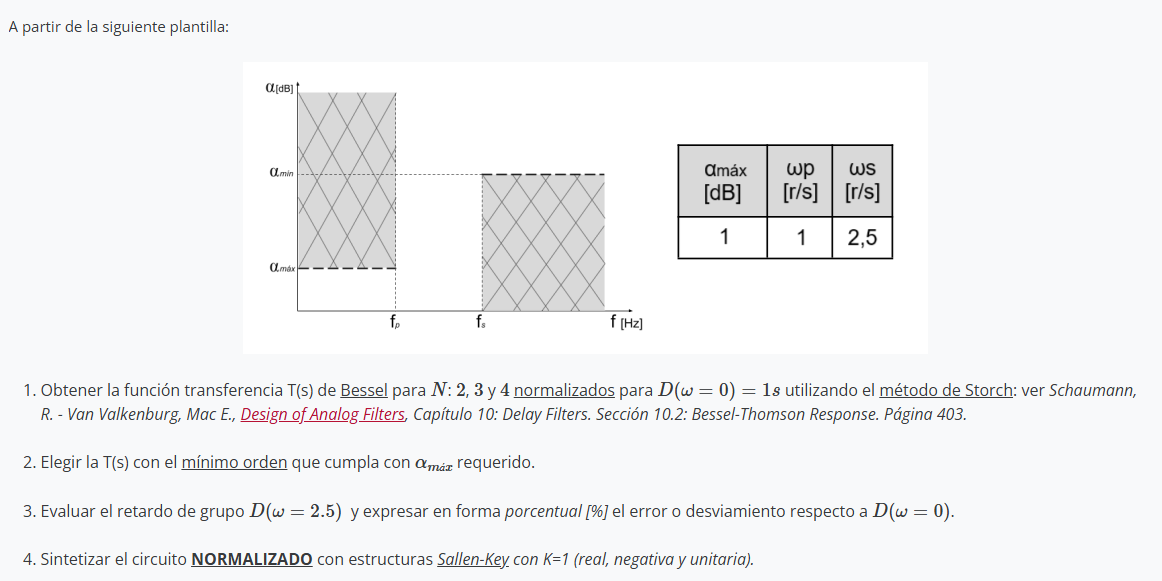

In [ ]:
import sympy as sp
import numpy as np
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pretty_print_SOS, tf2sos_analog
import scipy.signal as sig

In [ ]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# módulo de SciPy
from scipy import signal as sig

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})


### Funciones Transferencia por orden

**$n = 1$**

$$T_1(s) = \frac{1}{s + 1}$$

---

**$n = 2$**

$$\text{Cotgh} = \frac{1}{s} + \frac{1}{\frac{3}{s}} = \frac{1}{s} + \frac{s}{3} = \frac{s^2 + 3}{3s}$$

$$T_2(s) = \frac{1}{\cosh(s) + \sinh(s)} = \frac{1}{s^2 + 3s + 3} = \frac{1{,}73^2}{s^2 + s\,\frac{1{,}73}{Q} + 1{,}73^2}, \quad Q = \frac{\sqrt{3}}{3}$$

---

**$n = 3$**

$$\text{Cotgh} = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{1}{\dfrac{5}{s}}} = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{s}{5}}$$

$$= \frac{1}{s} + \frac{1}{\dfrac{s^2 + 15}{5s}} = \frac{1}{s} + \frac{5s}{s^2 + 15} = \frac{6s^2 + 15}{s^3 + 15s}$$

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

$$= \frac{2{,}32 \cdot (2{,}54)^2}{(s + 2{,}32)\left(s^2 + s\,\dfrac{2{,}54}{0{,}690} + (2{,}54)^2\right)}$$

---

**$n = 4$**

$$\text{Cotgh} = \frac{1}{s} + \cfrac{1}{\dfrac{3}{s} + \cfrac{1}{\dfrac{5}{s} + \dfrac{s}{7}}} = \frac{1}{s} + \frac{1}{\dfrac{3}{s} + \dfrac{7s}{s^2 + 35}}$$

$$= \frac{1}{s} + \frac{1}{\dfrac{10s^2 + 105}{s^3 + 35s}} = \frac{1}{s} \cdot \frac{s^3 + 35s}{10s^2 + 105}$$

$$= \frac{s^4 + 45s^2 + 105}{10s^3 + 105s}$$

$$T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}$$

---

### Verifico Condición

Busco la transferencia que cumpla con el $\alpha_{\min}$ solicitado.

$$T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}$$

$$\left|T_3(j1)\right| = \left|\frac{15}{-j.1^3 - 6.1^2 + 15j.1 + 15}\right|$$

$$= \frac{15}{\left|9 + 14j\right|} = \frac{15}{\sqrt{277}} \approx 0{,}9012 \approx 0{,}90 \text{ dB}$$

---

### Evaluacion del retardo de grupo en $D(\omega = 2,5)$


$$\mathcal{D}_3(\omega) = \frac{6\omega^4 + 45\omega^2 + 225}{\omega^6 + 6\omega^4 + 45\omega^2 + 225}$$
ver Schaumann, R. - Van Valkenburg, Mac E., Design of Analog Filters, Capítulo 10: Delay Filters. Sección 10.2: Bessel-Thomson Response. Página 402.

$$\mathcal{D}_3(\omega = 2{,}5) = 0{,}752$$

$$E_{[\%]} = \frac{\left|\mathcal{D}(2{,}5) - \mathcal{D}(0)\right|}{\mathcal{D}(0)} \cdot 100$$

$$E_{[\%]} = 24{,}8\%$$



Simulo las Transferencias de Bessel y sus $\alpha_{min}$

In [ ]:
def sim_aprox(aproxs, orders2analyze, ripple, attenuation):

    all_sys = []
    filter_names = []

    for (this_aprox, this_order, this_ripple, this_att) in zip(aproxs, orders2analyze, ripple, attenuation):
        if this_aprox == 'Bessel':

            z,p,k = sig.besselap(this_order, norm='delay')

        num, den = sig.zpk2tf(z,p,k)


        all_sys.append(sig.TransferFunction(num,den))

        this_label = this_aprox + '_ord_' + str(this_order) + '_rip_' + str(this_ripple)+ '_att_' + str(this_att)

        print_subtitle(this_label)
        # factorizamos en SOS's
        this_sos = tf2sos_analog(num, den)

        pretty_print_SOS(this_sos, mode='omegayq')

        filter_names.append(this_label)

    # el caracter "_" descarta la salida de la función
    _ = analyze_sys( all_sys, filter_names )

    return( all_sys, filter_names )

#### Aproximaciones de Bessel-Thompson

#### Bessel_ord_2_rip_1_att_40

<IPython.core.display.Math object>

#### Bessel_ord_3_rip_1_att_40

<IPython.core.display.Math object>

#### Bessel_ord_4_rip_1_att_40

<IPython.core.display.Math object>


--- Magnitud exacta en w = 1 ---
Orden 2 -> Magnitud: 0.8321 (veces) | -1.60 dB
Orden 3 -> Magnitud: 0.9013 (veces) | -0.90 dB
Orden 4 -> Magnitud: 0.9300 (veces) | -0.63 dB


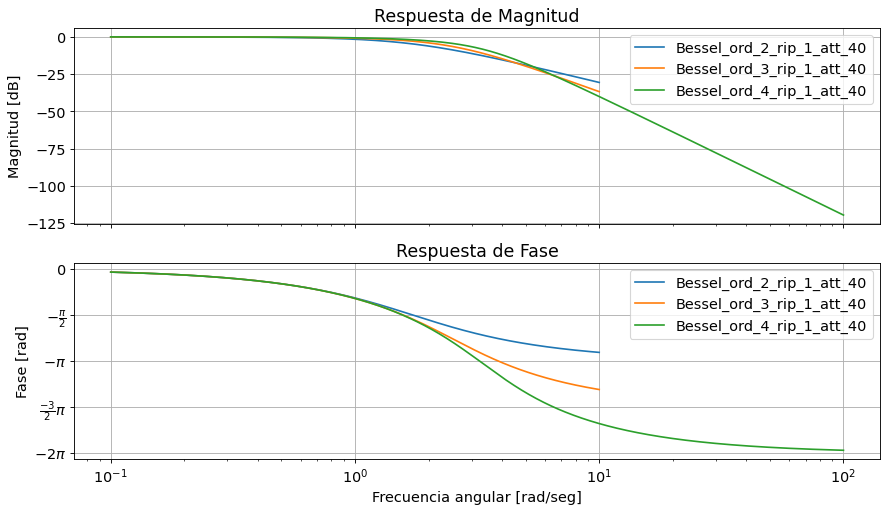

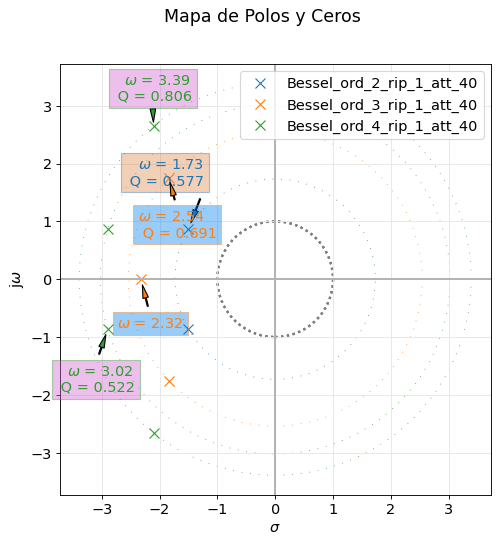

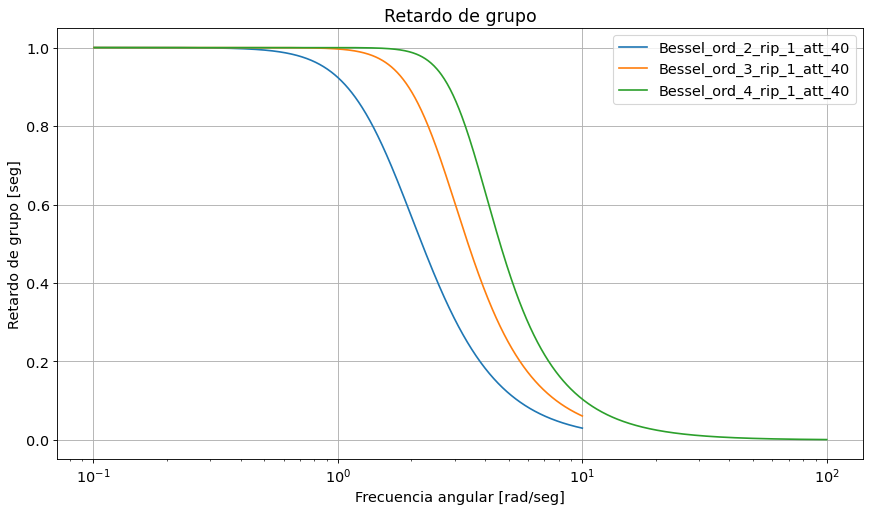

In [ ]:
from pytc2.general import print_subtitle
aprox_name = 'Bessel'

# parametrizamos el orden para cada aproximación
orders2analyze = [2, 3, 4]

# Mismo requerimiento de ripple y atenuación
aproxs = [aprox_name] * len(orders2analyze)
ripple = [1] * len(orders2analyze) # dB \alpha_{max} <-- Sin parametrizar, lo dejo en Butterworth
attenuation = [40] * len(orders2analyze) # dB \alpha_{min} <-- Sin parametrizar, att fija


print_subtitle('Aproximaciones de Bessel-Thompson')

( all_sys, filter_names ) = sim_aprox(aproxs, orders2analyze, ripple, attenuation)

##Con esto saco el alpha_min de la transferencia
print("\n--- Magnitud exacta en w = 1 ---")
for i, sys in enumerate(all_sys):
    num, den = sys.num, sys.den

    w, h = sig.freqs(num, den, worN=[1.0])

    magnitud_veces = np.abs(h[0])
    magnitud_db = 20 * np.log10(magnitud_veces)

    print(f"Orden {orders2analyze[i]} -> Magnitud: {magnitud_veces:.4f} (veces) | {magnitud_db:.2f} dB")


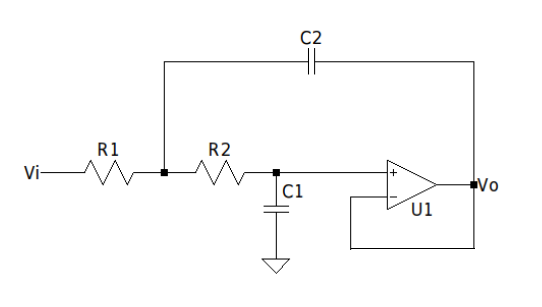


### Transferencia Sallen-Key

Nodo $V_a$:

$$V_a(G_1 + G_2 + sC_2) - V_i G_1 - V_b G_2 - V_o\, sC_2 = 0$$

Nodo $V_b$:

$$V_b(G_2 + sC_1) - V_a G_2 = 0 $$
$$ V_b = V_o$$

Substituyendo:

$$V_a = V_o\,\frac{G_2 + sC_1}{G_2}$$


$$\frac{V_o(G_2 + sC_1)}{G_2}(G_1 + G_2 + sC_2) - V_i G_1 - V_o G_2 - V_o\, sC_2 = 0$$

$$V_o\!\left(\frac{G_1 G_2 + G_2^2 + sG_2C_2 + sC_1G_1 + sC_1G_2 + s^2C_1C_2 - G_2^2 - sC_2G_2}{G_2}\right) = V_i G_1$$

$$V_o\!\left(\frac{s^2 C_1 C_2 + sC_1(G_1 + G_2) + G_1 G_2}{G_1 G_2}\right) = V_i$$

$$T(s) = \frac{G_1 G_2}{s^2 C_1 C_2 + sC_1(G_1 + G_2) + G_1 G_2}$$

$$T(s) = \frac{\dfrac{G_1 G_2}{C_1 C_2}}{s^2 + s\,\dfrac{G_1 + G_2}{C_2} + \dfrac{G_1 G_2}{C_1 C_2}}$$

para $G_1 = G_2 = 1$ :


$$T(s) = \frac{1}{s^2 + s\,\dfrac{2}{C_2} + \dfrac{1}{C_1 C_2}}$$

con $\Omega_\omega = \sqrt{\frac{1}{C_1 C_2}}$

$$T(s) = \frac{1}{s^2 + 2s\sqrt{\dfrac{C_1}{C_2}} + 1}$$

$$\sqrt{\frac{C_1}{C_2}} = \frac{1}{2Q} \implies \frac{C_1}{C_2} = \frac{1}{4Q^2}$$

$$C_1 = \frac{C_2}{4Q^2}, \quad C_1 = \frac{1}{C_2}$$

$$\boxed{C_2 = 2Q, \quad C_1 = \frac{1}{2Q}}$$


##Circuito Normalizado

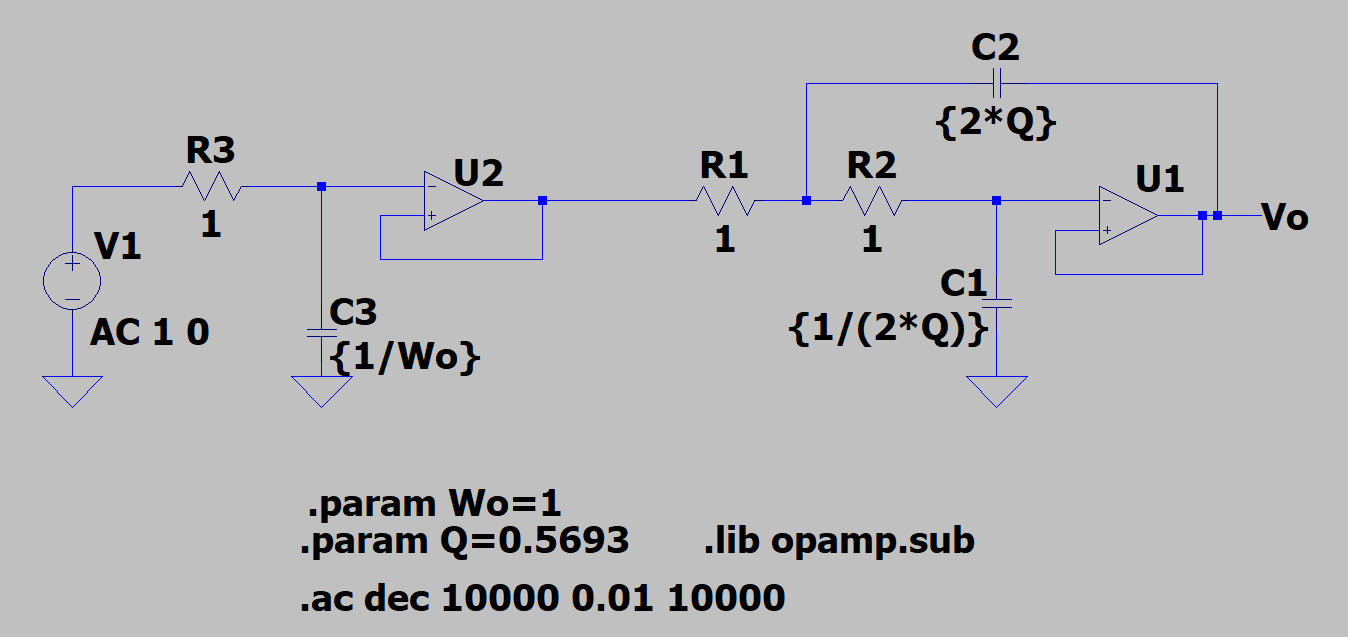

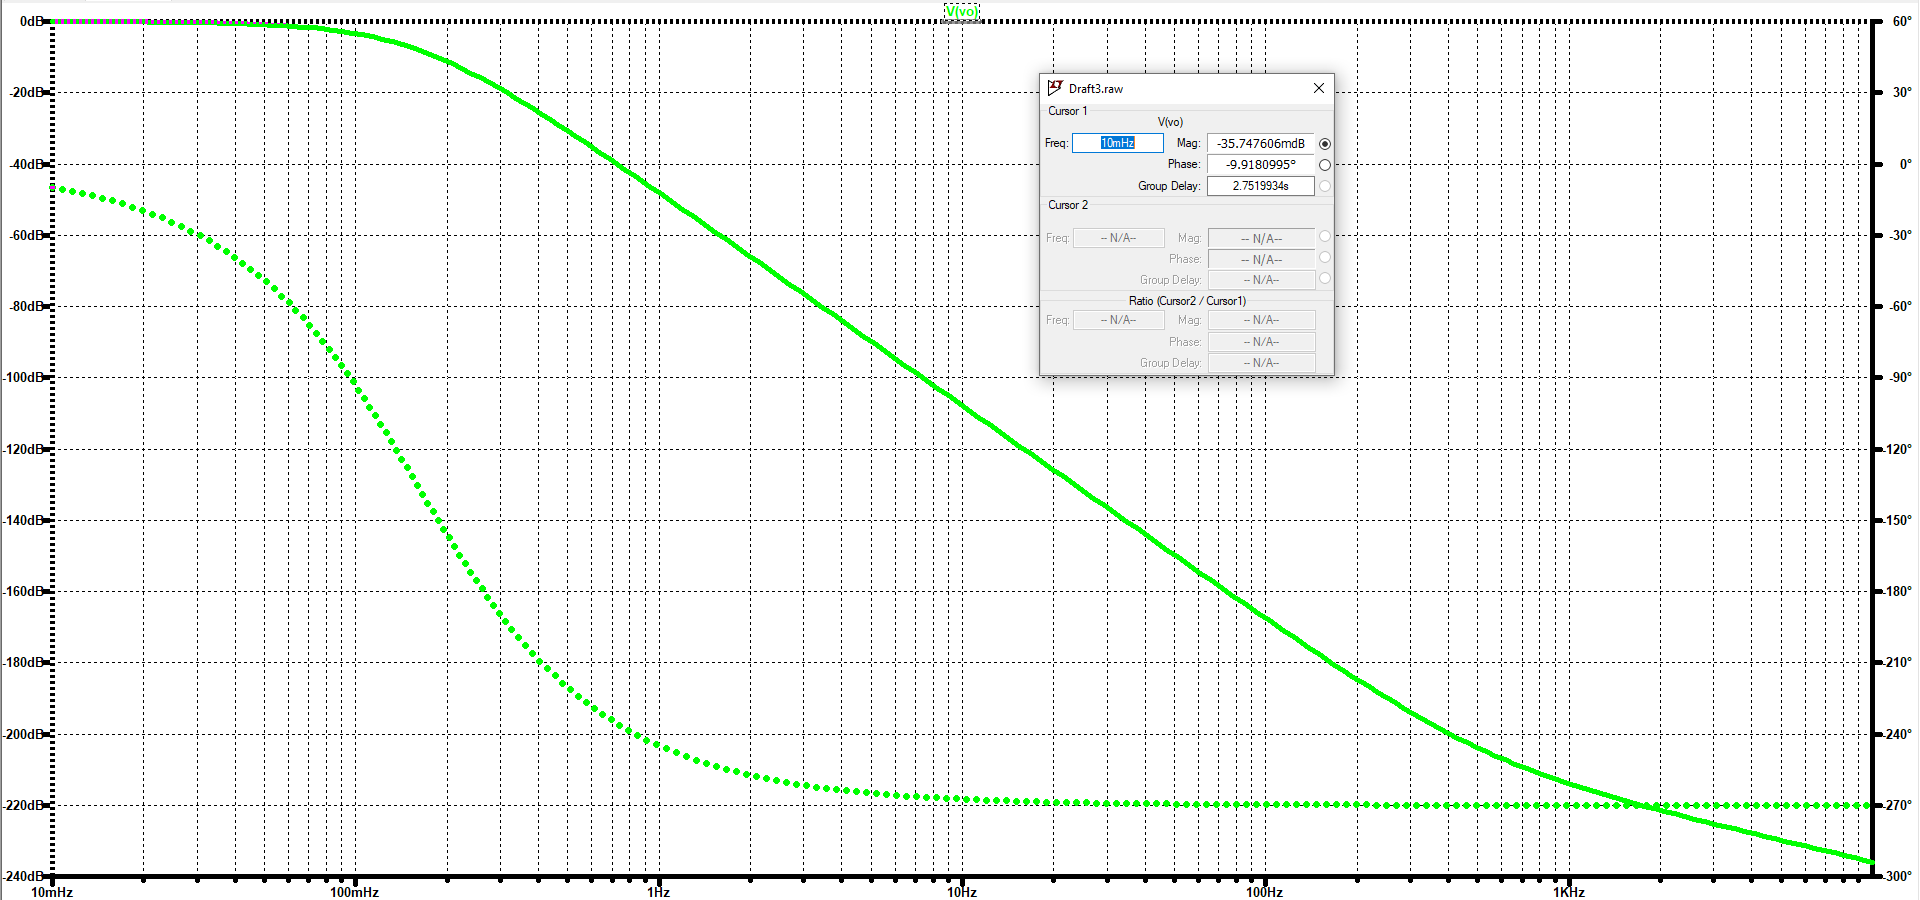

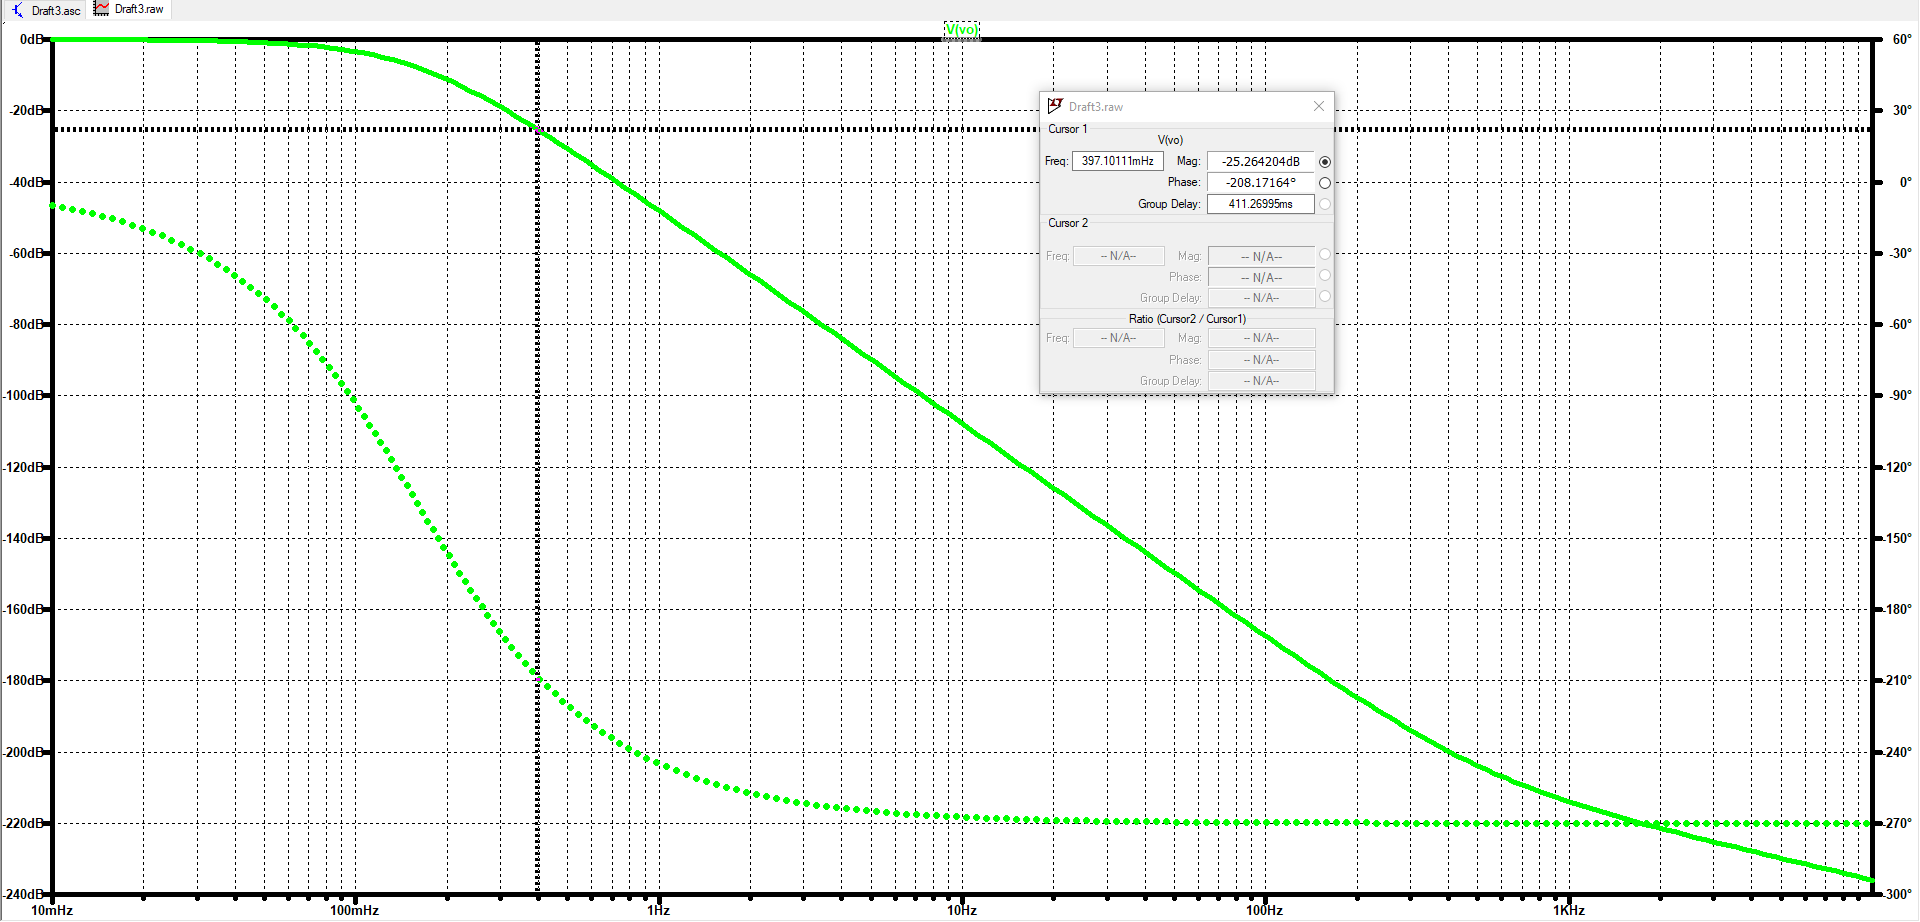

Se puede notar que no se cumplen las condiciones impuestas en la teoria. Esto se debe a que el retardo de grupo se modifico al normalizar por impedancia y frecuencia al circuito.

### Retardo de grupo para circuito normalizado

$$\mathcal{D}_1 = \frac{a_0}{a_0^2 + \omega^2}$$

Con $a_0 = 1$:

$$\mathcal{D}_1(\omega = 0) = 1s, \quad \mathcal{D}_1(\omega = 2{,}5) = 0{,}1379s$$

$$\mathcal{D}_2 = \frac{a_1}{a_0} \cdot \frac{1 + \dfrac{\omega^2}{a_0}}{1 + \omega^2\!\left(\dfrac{a_1^2}{a_0^2} - \dfrac{2}{a_0}\right) + \dfrac{\omega^4}{a_0}}$$

Con $a_1 = 1{,}7565$, $a_0 = 1$:

$$\mathcal{D}_2(\omega = 1) = 1{,}7565s, \quad \mathcal{D}_2(\omega = 2{,}5) = 0{,}2718s$$

Entonces:

$$\mathcal{D}(\omega = 1) = \mathcal{D}_1(\omega=1) + \mathcal{D}_2(\omega=1) = 2{,}7565s$$

$$\mathcal{D}(\omega = 2{,}5) = \mathcal{D}_1(\omega=2{,}5) + \mathcal{D}_2(\omega=2{,}5) = 0{,}4097s$$

Con estas cuentas se puede ver que al desnormalizar el circuito se veran reflejados los resultados obtenidos analiticamente.